## Generating training set of xTB water trajectories

At the time of this project, July 2026, the HPC facilities are inaccessible. Therefore, the training set generated here is generated on my home laptop, limiting the trajectories to small systems.

In [1]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md import Langevin
from ase.io import read, write

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 

import numpy as np

When training ML models, it's equally, if not more importnant, to sample a variety of different configurations. Here, a single water molecule will be stretched and bended to obtain a wide range of configurations.

## Creating water molecule

Systematically sampling configuration space.

In [82]:
# create water molecule 
water = molecule('H2O')

# get original angle
og_angle = water.get_angle(1, 0, 2)

water.set_angle(1, 0, 2, angle=20)
new_angle = water.get_angle(1, 0, 2)

# setting up range of bond lengths 
bond_lengths = np.linspace(0.8,1.1, 8)

# setting up range of bond angles
angles = np.linspace(103, 106, 5)

for theta in angles:
    # increase bond angle
    
    for length in bond_lengths:
  
        # set H-O-H angle
        theta = np.deg2rad(theta)

        pos = [[0.0, 0.0, 0.0],
                [0.0, 0.0, length],
                [length * np.sin(theta), length * np.cos(theta), 0.0]]

        # create water Atoms object with positions 
        water = molecule('H2O', positions=pos)
        
        # write current Atoms object 
        with open('water_sampling_1.xyz', 'a') as f:
            write(f, water, format='xyz')

print('Done systematic sampling.')


Done systematic sampling.


In [10]:
configs = read('water_sampling_1.xyz', index=':')
print(f'There are: {len(configs)} frames')

There are: 1320 frames


## Performing Single Point Calculators for water configurations

In [ ]:
from ase.calculators.tip3p import TIP3P 
from ase.calculators.cp2k import CP2K
import os 
from ase.md.nptberendsen import NPTBerendsen

# load all frames from .xyz file 
configs = read('water_sampling_1.xyz', index=':')
os.environ['OMP_NUM_THREADS'] = '8'

print(os.environ['OMP_NUM_THREADS'])

calc = CP2K(inp='''                                       
&FORCE_EVAL
  &DFT
    &QS
      METHOD xTB
      &XTB
        CHECK_ATOMIC_CHARGES F
        COULOMB_INTERACTION T
        DO_EWALD T
      &END XTB
    &END QS
    &SCF
      SCF_GUESS ATOMIC
      EPS_SCF 1.0E-6
      &OT
        MINIMIZER DIIS
        ENERGY_GAP 0.1
        PRECONDITIONER FULL_SINGLE_INVERSE
      &END OT
    &END SCF

    CHARGE 0 
    MULTIPLICITY 1
  &END DFT
  &SUBSYS
    &TOPOLOGY
        COORD_FILE_FORMAT XYZ
        COORD_FILE_NAME water_sampling_1.xyz
        
    &END TOPOLOGY
  &END SUBSYS
&END FORCE_EVAL
''')
# creating dataset fize in extended .xyz format
dataset = 'water_dataset.extxyz'

for i, atoms in enumerate(configs):
    # set cell size and pbc
    atoms.set_cell([20.0, 20.0, 20.0])
    atoms.set_pbc(True)
    
    # attach calculator 
    atoms.calc = calc 
    
    # calculate energy
    energy = atoms.get_potential_energy()
    # calculate forces 
    forces = atoms.get_forces()

    # write to .extendedxyz
    write(dataset, atoms, append=True)
    print(f'{i} out of 1320 frames done')

print('All single point calculations done')


8


## Randomising frames in extxyz

In [ ]:
# read in frames of extxyz 
# create new file
# randomise extxyz frames and write to new file 


## Creating water box

In [ ]:
water_molecules = molecule('H2O') # creating water molecule
n_molecules = 1 # number of molecules in cube 

density = 0.9982  # denisty of water in g/cm^3 at 20°C

total_mass = water_molecules.get_masses().sum() * n_molecules 
box_length = ((total_mass / units.mol) / (density * 1e-24)) ** (1/3)
# box length in Å

# make box bigger and tile 


water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()

# Repeat the water molecules, non uniformly
water_molecules *= (3,1,1) 

# manually reset water box to a cube 
#water_molecules.set_cell((box_length, box_length, box_length), scale_atoms=True)
#water_molecules.center()
water_molecules.set_pbc(True)

# RATTLE-type constraints on O-H1, O-H2, H1-H2.
water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(n_molecules) for j in [0, 1, 2]]
)

In [46]:
print(water_molecules.get_cell())      # should show equal lengths on diagonal
print(len(water_molecules))             # should be 9 (3 atoms × 3 molecules)
print(water_molecules.get_volume()) 

Cell([3.1061464666486716, 3.1061464666486716, 3.1061464666486716])
3
29.968554210874938


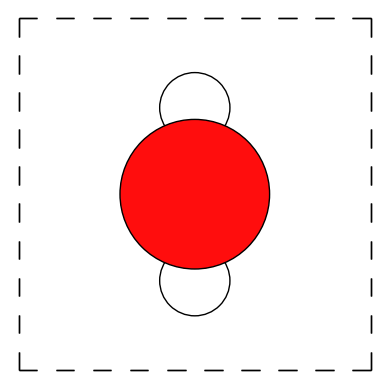

In [47]:
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
ax.set_axis_off()

Preparing for crude TIP3P equilibration for a box of 3 waters.

In [48]:
tag = 'tip3p_2water'
water_molecules.calc = TIP3P(rc=1)  # set the calculator to be the TIP3P force field

def print_stats(a):
    volume = a.get_volume()
    temp = a.get_temperature()
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    etot = ekin + epot
    print(
        f'Current Volume: {volume:.3f} '
        f'Current Temperature: {temp:.3f} K '
        f'Current total energy: {etot:.3f} eV '
    )

# initialise mb velocities
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)

# crude tip3p equilibration 
md = Langevin(
    water_molecules,
    1 * units.fs, # 1 fs timestep 
    temperature_K=300,  # 20 °C
    friction=0.01,
    logfile=tag+'.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)

print('Now starting equilibration of small box')
print_stats(water_molecules)
print_per = 20
for i in range(print_per):
    md.run(50)  #prints every 50 steps, 1000 steps total
    print_stats(water_molecules)
print('First equilibration done')



/tmp/ipykernel_52382/4040880347.py:17: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


Now starting equilibration of small box
Current Volume: 29.969 Current Temperature: 209.697 K Current total energy: 0.054 eV 
Current Volume: 29.969 Current Temperature: 277.066 K Current total energy: 0.072 eV 
Current Volume: 29.969 Current Temperature: 309.763 K Current total energy: 0.080 eV 
Current Volume: 29.969 Current Temperature: 260.581 K Current total energy: 0.067 eV 
Current Volume: 29.969 Current Temperature: 295.634 K Current total energy: 0.076 eV 
Current Volume: 29.969 Current Temperature: 235.334 K Current total energy: 0.061 eV 
Current Volume: 29.969 Current Temperature: 214.402 K Current total energy: 0.055 eV 
Current Volume: 29.969 Current Temperature: 175.877 K Current total energy: 0.045 eV 
Current Volume: 29.969 Current Temperature: 195.044 K Current total energy: 0.050 eV 
Current Volume: 29.969 Current Temperature: 286.213 K Current total energy: 0.074 eV 
Current Volume: 29.969 Current Temperature: 338.817 K Current total energy: 0.088 eV 
Current Volume

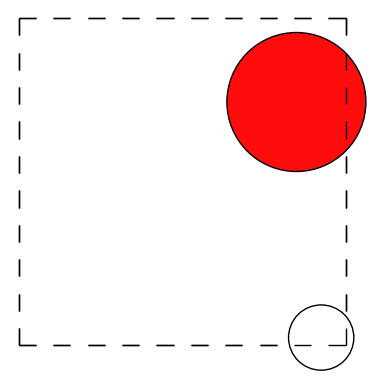

In [49]:
fig, ax = plt.subplots()
water_molecules.wrap()
plot_atoms(water_molecules, ax)
ax.set_axis_off()


In [35]:
print(water_molecules.cell)
print(water_molecules.positions)

Cell([3.1061464666486716, 3.1061464666486716, 3.1061464666486716])
[[5.48658131 3.6033938  2.36341343]
 [6.41211137 3.8108543  2.55955738]
 [4.98665544 4.14855984 2.9887024 ]]


Water MD with TIP3P, equilibrating with NVE

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance

from ase.calculators.tip4p import TIP3P
from ase import units
from ase.cluster.cubic import FaceCenteredCubic as ClusterFCC
from ase.io.trajectory import Trajectory
from ase.lattice.cubic import FaceCenteredCubic as LatticeFCC
from ase.md.langevin import Langevin  # for later NPT simulations
from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms
from ase.io import read, write

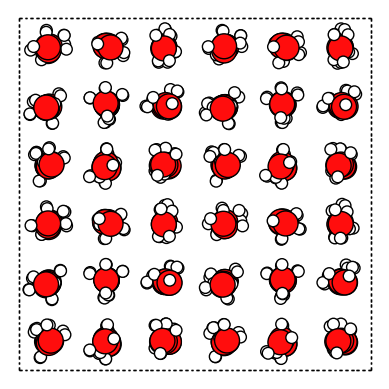

In [5]:
#pre equilibrated water 
#water_molecules = read('tip3p_equilibrated.traj')
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
#view(water_molecules)
ax.set_axis_off()

Equilibrating with NPT

8


/tmp/ipykernel_44191/2131536579.py:33: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


running a NPT simulation of equilibrated water 
Atoms(symbols='H432O216', pbc=True, cell=[18.63687879989203, 18.63687879989203, 18.63687879989203], momenta=..., constraint=<ase.constraints.fix_bond_lengths.FixBondLengths object at 0x5917ffb6de0>, calculator=CP2K(...))


/home/fh22600/miniforge3/envs/cp2k_env/lib/python3.14t/site-packages/ase/calculators/cp2k.py:323: UserWarning: ASE may stall when passing large structures to MPI versions of CP2K. Consider using `set_pos_file=True`.
  warn('ASE may stall when passing large structures'


Energy per atom: Epot =-33993.258eV  Ekin = 28.005eV (T=501.517K) Etot = -33965.253eV
Energy per atom: Epot =-33994.969eV  Ekin = 25.665eV (T=459.617K) Etot = -33969.303eV
Energy per atom: Epot =-33997.637eV  Ekin = 25.183eV (T=450.991K) Etot = -33972.453eV
Energy per atom: Epot =-33998.451eV  Ekin = 23.343eV (T=418.036K) Etot = -33975.107eV
Energy per atom: Epot =-34001.831eV  Ekin = 24.314eV (T=435.421K) Etot = -33977.517eV
Energy per atom: Epot =-34004.527eV  Ekin = 24.589eV (T=440.354K) Etot = -33979.938eV
Energy per atom: Epot =-34005.161eV  Ekin = 22.811eV (T=408.509K) Etot = -33982.349eV
Energy per atom: Epot =-34007.055eV  Ekin = 22.793eV (T=408.186K) Etot = -33984.261eV
Energy per atom: Epot =-34007.466eV  Ekin = 21.386eV (T=382.991K) Etot = -33986.080eV
Energy per atom: Epot =-34009.156eV  Ekin = 21.665eV (T=387.986K) Etot = -33987.491eV
Energy per atom: Epot =-34010.816eV  Ekin = 21.831eV (T=390.958K) Etot = -33988.984eV
Energy per atom: Epot =-34012.134eV  Ekin = 21.585eV (

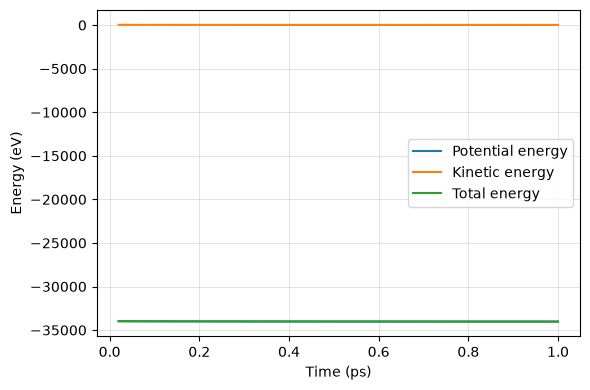

In [9]:
from ase.calculators.cp2k import CP2K
import os 
from ase.md.nptberendsen import NPTBerendsen
os.environ['OMP_NUM_THREADS'] = '8'

print(os.environ['OMP_NUM_THREADS'])

water_molecules.calc = CP2K(inp='''&FORCE_EVAL
  &DFT
    &QS
      METHOD xTB
      &XTB
        CHECK_ATOMIC_CHARGES F
        COULOMB_INTERACTION T
        DO_EWALD T
      &END XTB
    &END QS
    &SCF
      SCF_GUESS RESTART
      EPS_SCF 1.0E-6
      &OT
        MINIMIZER DIIS
        ENERGY_GAP 0.1
        PRECONDITIONER FULL_SINGLE_INVERSE
      &END OT
    &END SCF
  &END DFT
&END FORCE_EVAL
''')

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 2 # to capture hydrogen bonding interactions, time step short 
#dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  #  fs time step.
dyn = NPTBerendsen(water_molecules, timestep=2 * units.fs, temperature_K=300,
                   taut=100 * units.fs, pressure_au=1.01325 * units.bar,
                   taup=1000 * units.fs, compressibility_au=4.57e-5 / units.bar)

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NPT simulation of equilibrated water ')
print(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 10

traj = Trajectory('xtb_test'+ '.traj', 'w', water_molecules)

# write to trajectory every 
dyn.attach(traj.write, interval=1) 

# each iteration up to 200 is one block of 2 steps 
for i in range(50):

    
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)

    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

traj.close()
# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


In [11]:
from ase.visualize import view
print(len(water_molecules))

view(water_molecules)

# save trajectory and save last frame 

648


<Popen: returncode: None args: ['/home/fh22600/miniforge3/envs/cp2k_env/bin/...>

Water box has no kinetic energy, has reached lowest energy structure

## Visualise trajectories


In [ ]:
# visualise xtb_test.traj 
# ase gui xtb_test.traj 

(20,)

1. Get equilibrated and thermolised box using berendsten at npt, print out / save box dimensions and water coordinates once trajectories are random enough. (1 fs timestep), total duration ~ 1000 fs to get totally random configuration, and write every 100 frames.
2. Get final frame to get equilibrated and thermolised water box.
3. Switch to velocity verlet to run NVE simulation, basically running equilibrium MD of water. (2 fs timestep)
4. For equilibrium MD, write to trajectory every 5 frames.

### Generating training data from equilibrium MD runs

1. trajectories will be saved as extended .xyz files
2. Select a starting water box configuration
3. In a for loop,  generate random velocities with maxwell distribution and get 100 frames

OR 

1. Select last 10 MD frames
2. From each frame, run MD with randomly generated velocities and get 100 frames.


# Generating training dataset from xTB run

In [36]:
# skip first frames of long xtb run for equilibration 
skip = 150

trajectory = Trajectory('xtb_test.traj')
frames = len(traj)
print(f'Trajectory file has {frames} frames')
interval = 50

# 8 starting configs 
sampled_duration = list(range(skip, frames, interval))
print(f'Sampling from {sampled_duration} fs')

# get xyz file
directory = 'starting_configs'
for i, idx in enumerate(sampled_duration):
    atoms = trajectory[idx]
    write(f'{directory}/start_{i}.xyz', atoms)
    print(f'Written {i}th .xyz file')


# initialise velocities again 


Trajectory file has 501 frames
Sampling from [150, 200, 250, 300, 350, 400, 450, 500] fs
Written 0th .xyz file
Written 1th .xyz file
Written 2th .xyz file
Written 3th .xyz file
Written 4th .xyz file
Written 5th .xyz file
Written 6th .xyz file
Written 7th .xyz file
